In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
from py_wake.examples.data.lillgrund import LillgrundSite
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.examples.data.iea37 import IEA37_WindTurbines
from py_wake.deficit_models.gaussian import IEA37SimpleBastankhahGaussian

from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from topfarm import TopFarmProblem
from topfarm.plotting import NoPlot
from topfarm.easy_drivers import EasyScipyOptimizeDriver

In [4]:
site = LillgrundSite()
windTurbines = IEA37_WindTurbines()

wf_model = IEA37SimpleBastankhahGaussian(site, windTurbines,deflectionModel=JimenezWakeDeflection())

#choosing the flow cases for the optimization
wsp = np.asarray([10])
wdir = np.asarray([270])

#getting initial position of turbines
x,y = site.initial_position.T
x = x[::2]
y = y[::2]
n_wt = x.size

#setting up yaw angles for each turbine, wind direction and wind speed
i = n_wt
k = wsp.size
l = wdir.size
yaw_zero = np.zeros((i,l,k))  #initial condition of yaw angles

In [5]:
def aep_func(yaw_ilk):
    simres = wf_model(x,y,wd=wdir,ws=wsp,yaw=yaw_ilk, tilt=0)
    aep = simres.aep().sum()
    return aep

In [6]:
cost_comp = CostModelComponent(input_keys=[('yaw_ilk', np.zeros((i, l, k)))],
                                          n_wt = n_wt,
                                          cost_function = aep_func,
                                          objective=True,
                                          maximize=True,
                                          output_keys=[('AEP', 0)]
                                          )

maxiter=30
tol=1e-4
ec=1e-4

problem = TopFarmProblem(design_vars={'yaw_ilk': (yaw_zero, -30, 30)},  #setting up initial values and lower and upper bounds for yaw angles
                          n_wt=n_wt,
                          cost_comp=cost_comp,
                          driver=EasyScipyOptimizeDriver(optimizer='SLSQP', maxiter=maxiter, tol=tol),
                          plot_comp=NoPlot(),
                          expected_cost=ec)

INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000216 sec).
INFO: checking system...
INFO:     system check complete (0.000004 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000045 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000014 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.000002 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.000126 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000022 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.000003 sec).


In [7]:
_, state,_ = problem.optimize()

INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000059 sec).
INFO: checking system...
INFO:     system check complete (0.000004 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000043 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000011 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.000002 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.000044 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000011 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.000002 sec).
Iteration limit reached    (Exit mode 9)
            Current function value: -1384946.0060481748
            Iterations: 30
            Function evaluations: 84
            Gradient evaluations: 30
Optimization FAILED.
Iteration limit reached
-----------------------------------


Text(0, 0.5, 'y [m]')

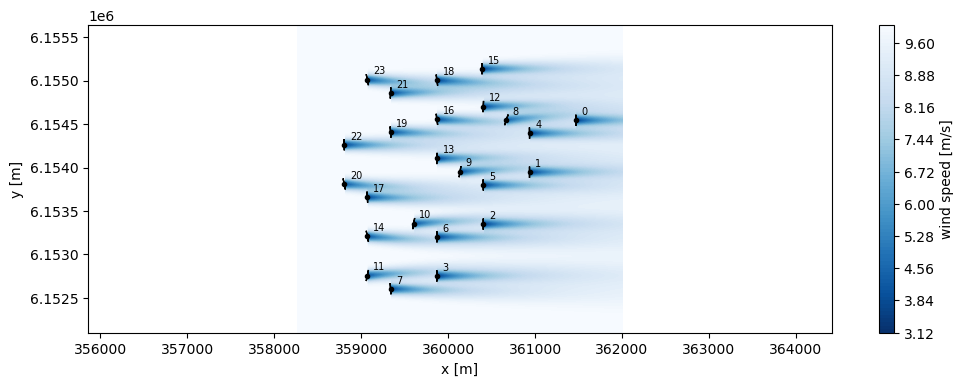

In [8]:
simulationResult = wf_model(x,y,wd=wdir[0], ws=wsp[0], yaw=state['yaw_ilk'][:,0,0], tilt=0)
plt.figure(figsize=(12,4))
simulationResult.flow_map().plot_wake_map()
plt.xlabel('x [m]')
plt.ylabel('y [m]')